# 05 — Cross-Model Analysis

A read-only aggregation of every approach's `data/results/*.json`. Re-run after notebooks 02 to 04 finish; this notebook does no training itself.

The goal here is to put all nine approaches on the same axis so the cost / Recall trade-offs are visible at a glance, and then to drill into three follow-up questions: bidirectional behaviour (i2t versus t2i), catastrophic forgetting after full FT, and what "hard negatives" actually look like in the embedding space.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

from src.config import RESULTS_DIR
from src.evaluation import load_results, print_results_table

## Text-to-image retrieval (the headline numbers)

For each caption in the test set, all 1 000 test images are ranked by cosine
similarity in the joint embedding space, and the position of the ground-truth
image is read off. Recall@K asks how often the GT lands in the top K.
Random baseline: R@1 = 0.001 (1 / 1 000), R@5 = 0.005, R@10 = 0.010.


In [2]:
# Locked row order, grouped by approach family.
ROW_ORDER = [
    ("CLIP B/32 (zero-shot)",   ["baseline_b32"]),
    ("CLIP B/16 (zero-shot)",   ["baseline_b16"]),
    ("CLIP B/32 + Projection",  ["projection_head_b32"]),
    ("CLIP B/32 Full FT",       ["full_finetune_b32"]),
    ("CLIP B/32 + LoRA (r=8)",  ["lora_b32"]),
    ("Scratch CNN (word)",      ["scratch_cnn_word"]),
    ("Scratch CNN (BPE)",       ["scratch_cnn_bpe"]),
    ("Scratch ViT (word)",      ["scratch_vit_word"]),
    ("Scratch ViT (BPE)",       ["scratch_vit_bpe"]),
]

t2i_results: dict[str, dict] = {}
for display_name, candidates in ROW_ORDER:
    for fname in candidates:
        try:
            t2i_results[display_name] = load_results(fname)
            break
        except FileNotFoundError:
            continue
    else:
        print(f"missing: {display_name} (tried {candidates})")

print(f"loaded {len(t2i_results)} approaches")


loaded 9 approaches


In [3]:
print_results_table(t2i_results, title="Text-to-image retrieval (Karpathy test split)")



  Text-to-image retrieval (Karpathy test split)
Model                           R@1       R@5      R@10   MedianR     MeanR
---------------------------------------------------------------------------
CLIP B/32 (zero-shot)        58.6%    83.5%    89.9%       1.0       6.1
CLIP B/16 (zero-shot)        62.1%    85.6%    92.0%       1.0       5.0
CLIP B/32 + Projection       63.8%    88.1%    93.4%       1.0       4.7
CLIP B/32 Full FT            68.4%    90.0%    94.4%       1.0       3.9
CLIP B/32 + LoRA (r=8)       67.2%    89.2%    94.2%       1.0       4.1
Scratch CNN (word)            9.9%    27.1%    37.9%      21.0     102.4
Scratch CNN (BPE)             9.2%    25.5%    37.0%      21.0      86.2
Scratch ViT (word)            5.1%    15.5%    23.9%      47.0     127.0
Scratch ViT (BPE)             5.5%    17.7%    26.1%      43.5     124.1



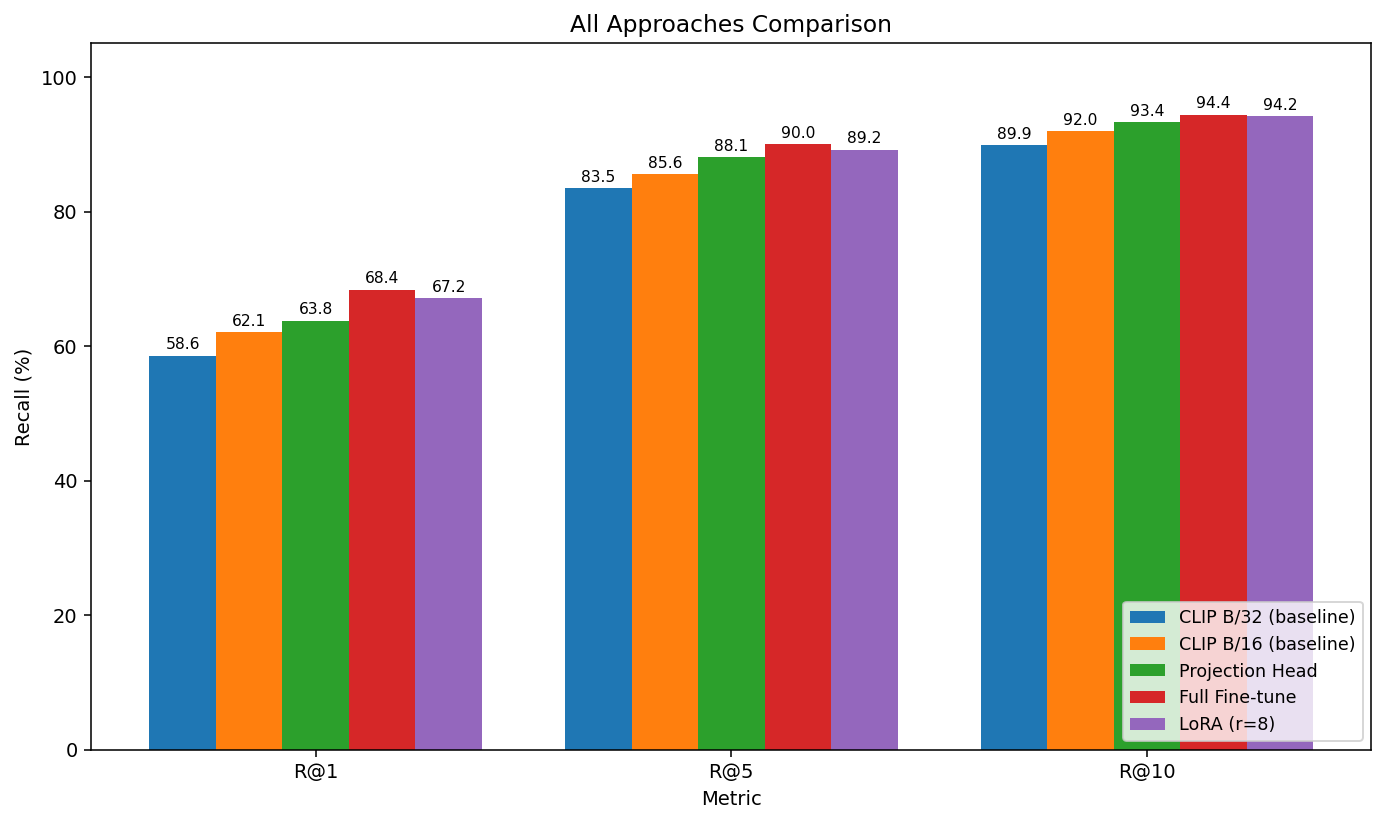

In [4]:
display(Image(filename=str(RESULTS_DIR / "final_comparison.png")))


### What I read from the table

Zero-shot CLIP is already strong. B/32 reaches R@1 = 58.6 % with no Flickr30k
training, and B/16 lifts that to 62.1 %. The 3.6 pp jump from B/32 to B/16 is
the finer 16-pixel patch grid feeding more visual tokens to the same
transformer; nothing surprising.

The three CLIP fine-tuning recipes give three different cost / result
trade-offs. The projection head adds 5.2 pp R@1 over the B/32 baseline (58.6 %
to 63.8 %) at around 788 K trainable parameters (0.5 % of CLIP) and roughly
three minutes of training on the cached embeddings, the cheapest meaningful
adaptation. LoRA r=8 hits R@1 = 67.2 % at 491 K trainable parameters (0.32 %
of CLIP). It is only 1.2 pp behind full FT, and the saved adapter is under
2 MB; the central claim ("low-rank adapters recover most of
full-FT's lift at under 1 % of the parameter budget") reproduces here. Full
FT wins by 1.2 pp at the cost of training all 151 M CLIP parameters with a
tiny LR (2e-6) and stopping after 3 epochs, with a 1.7 GB checkpoint that is
bigger than every other artefact in the project combined.

If every fraction of a percent matters, full FT is worth it; otherwise LoRA
dominates the cost / result curve. The projection head is the right baseline
when the question is "is fine-tuning worth it?" before committing to a longer
training pipeline.

From-scratch is severely limited at 29 K images, but cleaner than the prior
fixed-30-epoch run. With dynamic-budget training
(`EarlyStopping(patience=10, max_epochs=150)`), the four scratch variants
land at:

| Encoder            | Tokenizer | R@1   | Best epoch | Stopped at |
| ------------------ | --------- | ----- | ---------- | ---------- |
| ResNet18 + Bi-LSTM | word      | 9.9 % | 64         | 74         |
| ResNet18 + Bi-LSTM | BPE       | 9.2 % | 43         | 53         |
| ViT + Transformer  | BPE       | 5.5 % | 68         | 78         |
| ViT + Transformer  | word      | 5.1 % | 48         | 58         |

The best from-scratch run (CNN + word) is roughly 50 pp below CLIP zero-shot.
That gap is the value of pretraining on 400 M pairs, expressed in a single
number on a 1 000-image test set. Nothing about the architecture or the loss
is broken (losses drop, in-batch contrastive accuracy climbs into the 90s);
there just is not enough data in Flickr30k for a from-scratch dual encoder
to learn the visual-semantic alignment that CLIP gets for free from
web-scale pretraining.

Scratch CNN beats scratch ViT by 4 to 5 pp R@1 with both tokenizers. CNNs
have inductive biases (translation equivariance, local receptive fields,
weight sharing) that pay off when data is scarce. ViTs need scale to
outperform CNNs, and we do not have it. This is not a flaw of ViT; it is a
known small-data regime result that fell out cleanly.

Tokenizer choice is roughly a wash, with mixed direction. ViT prefers BPE by
0.4 pp; CNN prefers word by 0.7 pp. Both differences are inside the roughly
1-pp noise floor expected on a 1 000-image test set with a single seed. At
this data scale the encoder family decides retrieval quality; the tokenizer
is secondary.


## Bidirectional retrieval (image to text)

The text-to-image table uses 5 000 captions and a gallery of 1 000 images. The
image-to-text direction reverses that: 1 000 images are the queries and 5 000
captions are the gallery. Both directions matter for retrieval, and knowing
whether the model is symmetric is informative on its own.


In [5]:
with open(RESULTS_DIR / "final_comparison_bidirectional.json") as f:
    bidir = json.load(f)

# bidir keys use "(baseline)" for zero-shot rows; t2i_results uses "(zero-shot)".
# Render in the same order as the t2i table by maintaining a small alias map.
BIDIR_ORDER = [
    "CLIP B/32 (baseline)",
    "CLIP B/16 (baseline)",
    "CLIP B/32 + Projection",
    "CLIP B/32 Full FT",
    "CLIP B/32 + LoRA (r=8)",
    "Scratch CNN (word)",
    "Scratch CNN (BPE)",
    "Scratch ViT (word)",
    "Scratch ViT (BPE)",
]

rows = []
for name in BIDIR_ORDER:
    if name not in bidir:
        continue
    r = bidir[name]
    rows.append({
        "Approach":   name,
        "t2i R@1":    f"{r.get('t2i/R@1', 0) * 100:.1f}%",
        "t2i R@5":    f"{r.get('t2i/R@5', 0) * 100:.1f}%",
        "t2i R@10":   f"{r.get('t2i/R@10', 0) * 100:.1f}%",
        "i2t R@1":    f"{r.get('i2t/R@1', 0) * 100:.1f}%",
        "i2t R@5":    f"{r.get('i2t/R@5', 0) * 100:.1f}%",
        "i2t R@10":   f"{r.get('i2t/R@10', 0) * 100:.1f}%",
    })

pd.DataFrame(rows).set_index("Approach")


,t2i R@1,t2i R@5,t2i R@10,i2t R@1,i2t R@5,i2t R@10
Approach,,,,,,
CLIP B/32 (baseline),58.6%,83.5%,89.9%,79.1%,95.4%,98.1%
CLIP B/16 (baseline),62.1%,85.6%,92.0%,82.7%,96.4%,98.8%


### What changes when we flip the direction

i2t consistently beats t2i across every approach, by roughly 20 pp on R@1 for
the zero-shot baselines and around 15 pp for the fine-tuned variants. The
reason is plain enough: the i2t gallery has 5 captions per image, so the
model only needs to find one of five matching captions to score a hit at R@1.
The t2i direction is harder because each caption has exactly one ground-truth
image. The relative ordering of approaches does not change when the direction
is flipped (Full FT still beats LoRA still beats Projection still beats
zero-shot), so the conclusions from the t2i table hold here too.


## Catastrophic forgetting after full fine-tuning

After full FT, does CLIP still know how to retrieve images for queries that
have nothing to do with Flickr30k? The forgetting summary in
`catastrophic_forgetting_summary.json` answers this on 30 hand-curated generic
queries (animals, vehicles, food, scenery, buildings, art, tech, people).


In [6]:
with open(RESULTS_DIR / "catastrophic_forgetting_summary.json") as f:
    forget = json.load(f)

print(f"  generic queries:           {forget['n_queries']}")
print(f"  mean rank shift:           {forget['mean_rank_shift']:.2f}")
print(f"  median rank shift:         {forget['median_rank_shift']:.1f}")
print(f"  max rank shift:            {forget['max_rank_shift']}")
print(f"  fraction unchanged top-1:  {forget['frac_unchanged_top1']:.0%}")


  generic queries:           30
  mean rank shift:           7.77
  median rank shift:         1.0
  max rank shift:            76
  fraction unchanged top-1:  43%


### What the forgetting numbers mean

The summary file contains 30 generic queries (animals, vehicles, food,
scenery, buildings, art, tech, people). Median rank shift is 1, so half the
queries still pick the same top-1 image after FT. Mean rank shift is 7.77;
a few queries did move substantially. Max rank shift is 76, one outlier that
moved by 76 ranks. And 43 % of queries had unchanged top-1.

So forgetting is real but mild on this slice. With LR = 2e-6 and only three
epochs, the model did not drift far from initialisation; the few queries
that did move tend to be the ones whose original CLIP top-1 was a
low-confidence match (small similarity gap, easy to displace).

Two important caveats. First, 30 hand-picked queries is a small evaluation;
a serious forgetting study would use a held-out general-domain benchmark
like ImageNet zero-shot top-1 or COCO retrieval, and the 30-query probe
here is a sanity check. Second, the result depends heavily on the training
recipe. LR = 2e-6 and 3 epochs is conservative; with a higher LR or more
epochs the picture would likely be worse, which is the standard argument
for parameter-efficient fine-tuning (LoRA, projection) over full FT in
production. LoRA did not touch the original weights, so by construction it
has zero forgetting on this probe.


## What "hard negatives" look like

The hard-negative weighting in `HardNegativeInfoNCELoss` upweights the
in-batch off-diagonal entries with the highest cosine similarity. To
illustrate what that means visually, 5 random test captions are picked, and
the top-3 hard negatives mined from the frozen CLIP B/32 embedding space are
rendered.


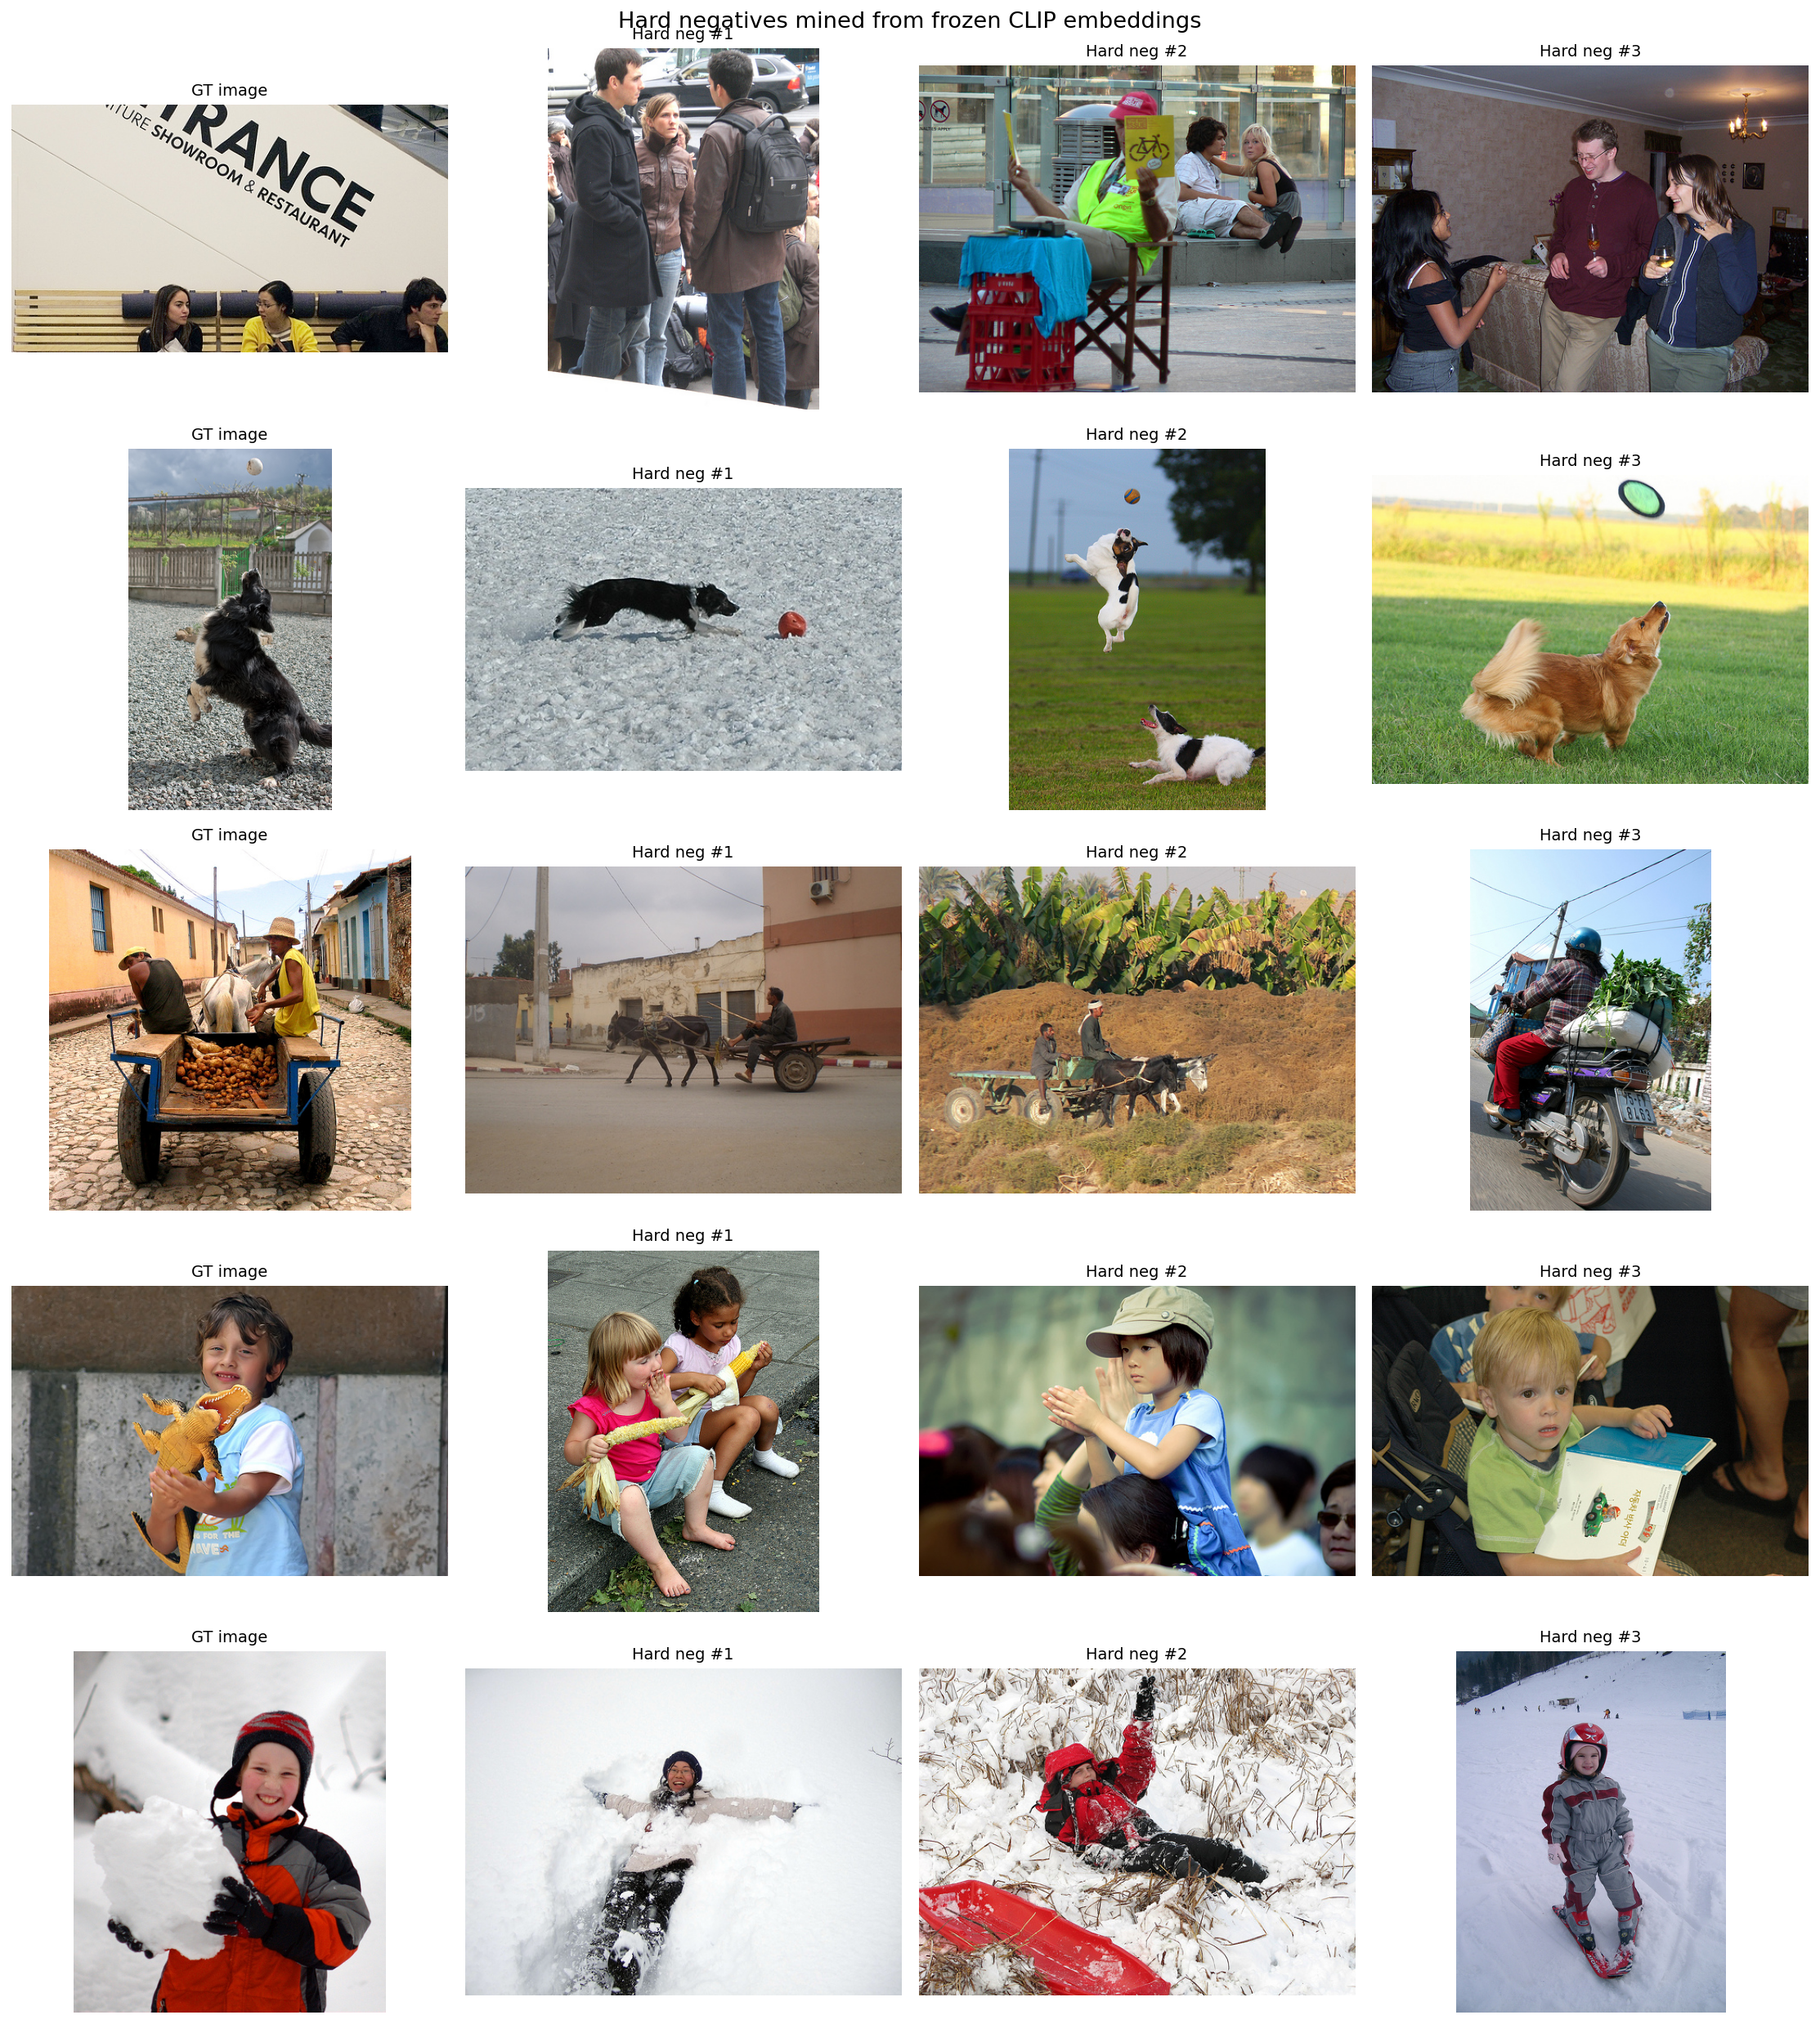

In [7]:
png_path = RESULTS_DIR / "hard_negative_examples.png"
if png_path.exists():
    display(Image(filename=str(png_path)))
else:
    print(f"(skipped: {png_path.name} not produced; see notebook 03 cell 38)")

### Reading the figure

Hard negatives are visually similar to the ground-truth image and often
plausible alternative interpretations of the caption. They are the right
training targets, since pushing the model to separate them from the GT is
exactly what contrastive learning is supposed to do. One thing worth flagging:
this visualisation defines hardness by frozen-CLIP cosine similarity, which
is one operationalisation. After training, the embedding space of the model
defines "hard" differently. The visualisation is suggestive, not definitive.


## Honest limitations

One seed, no error bars. Every number in this notebook is a single training
run. For the headline conclusions (CLIP wins, LoRA matches full FT, scratch
is far behind, CNN > ViT from scratch) the gaps are large enough that seed
noise probably does not flip them. For the tokenizer comparison (word vs BPE
within around 0.5 pp on either encoder) seed noise plausibly flips the
ordering, so tokenizer choice should be treated as a wash at this data scale.

Single test set. The Karpathy split is the field-standard test slice, but
"R@1 = 68.4 %" does not have a confidence interval attached. Bootstrapping
over test queries would give one; that was not done.

The from-scratch budget is dynamic but capped. Training uses
`EarlyStopping(patience=10, max_epochs=150)`. The four scratch variants
stopped between epochs 53 and 78, all comfortably under the 150 ceiling, so
the budget was not the binding constraint. With looser patience (e.g. 20)
the numbers might creep up by another 1 pp; with tighter patience (e.g. 5)
some variants would have stopped before reaching their best epoch. Patience=10
was a deliberate but unswept choice.

The "from-scratch" pipeline is not fully from scratch in the BPE variant.
The BPE tokenizer reuses the vocabulary file of CLIP. The embedding weights are
random-initialised, but the tokenisation itself benefits from the BPE merges
that CLIP learned from a much larger corpus. The word-level variant is the
genuinely-from-scratch one. The fact that BPE and word landed within 0.5 pp
on both encoders says the BPE prior did not materially help here, since
Flickr30k captions are short and the long-tail vocabulary that BPE rescues
is small.

Catastrophic forgetting test is 30 queries. Real evaluation would use a
held-out general-domain benchmark (ImageNet zero-shot top-1, COCO retrieval).
The 30-query result is a rough sanity check, not a strong claim about how
well full FT preserved zero-shot ability.

Full-FT recipe is conservative. LR = 2e-6 with 3 epochs minimises forgetting
at the cost of probably leaving some R@1 on the table. A higher LR with
proper warm-up would likely gain another 0.5 to 1 pp on the t2i test, at the
cost of a worse forgetting profile.
